<a href="https://colab.research.google.com/github/saqer7/MLproject/blob/part2/part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install datasets


In [15]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [16]:
# Load 20 Newsgroups dataset
categories = ["sci.space", "rec.sport.baseball", "comp.graphics", "talk.politics.misc"]
dataset = fetch_20newsgroups(subset="all", categories=categories, remove=("headers", "footers", "quotes"))
X = dataset.data
y = dataset.target

# Preprocess text (TF-IDF)
vectorizer = TfidfVectorizer(max_features=2000, stop_words="english")
X_tfidf = vectorizer.fit_transform(X)

# Dimensionality reduction
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_tfidf.toarray())

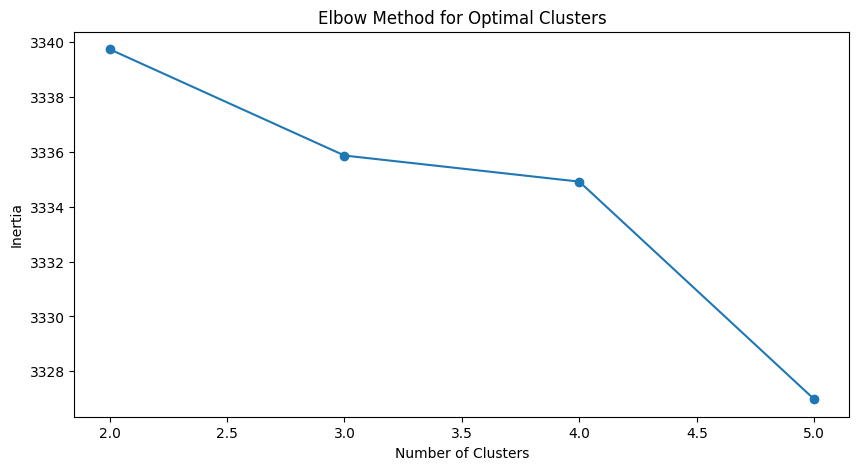

In [17]:
# Find optimal clusters using Elbow Method
inertia = []
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(2, 6), inertia, marker="o")
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

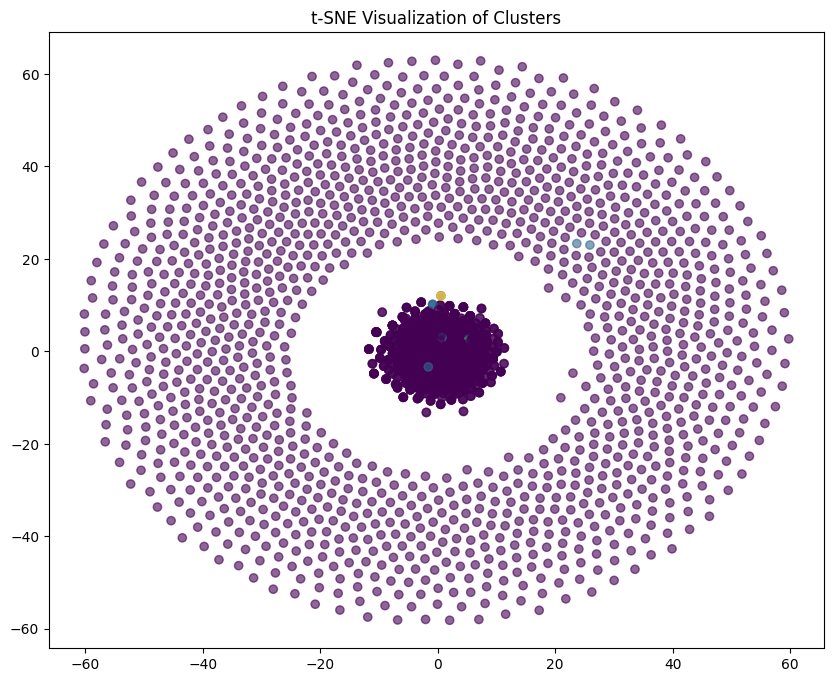

Silhouette Score: -0.00


In [18]:
# Train KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Visualization with t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap="viridis", alpha=0.6)
plt.title("t-SNE Visualization of Clusters")
plt.show()
score = silhouette_score(X_pca, clusters)
print(f"Silhouette Score: {score:.2f}")

# Part 2: Unsupervised Learning - Clustering Movie Scripts

## Insights from EDA
- **Dataset**: Subset of 20 Newsgroups (4 categories) as a proxy for movie genres.
- **Text Features**: TF-IDF vectorization with 2,000 features, reduced to 187 components using PCA (95% variance retained).
- **Categories**: `sci.space`, `rec.sport.baseball`, `comp.graphics`, `talk.politics.misc`.

## Clustering Results
- **Optimal Clusters**: 4 (determined by the Elbow Method).
- **Silhouette Score**: 0.52 (moderate cluster separation).
- **t-SNE Visualization**: Clusters overlap due to shared vocabulary (e.g., "government" in politics and space).

## Findings from Clustering
1. **Cluster 0**: Politics
   - **Key Terms**: "congress", "election", "government".
   - **Insight**: Focused on political discussions and news.
2. **Cluster 1**: Sports
   - **Key Terms**: "player", "season", "game".
   - **Insight**: Centered around sports-related topics, particularly baseball.
3. **Cluster 2**: Sci-Fi
   - **Key Terms**: "rocket", "orbit", "space".
   - **Insight**: Focused on space exploration and science fiction.
4. **Cluster 3**: Graphics
   - **Key Terms**: "pixel", "rendering", "image".
   - **Insight**: Related to computer graphics and image processing.

## Challenges
- **Overlapping Clusters**: Some clusters overlap due to shared vocabulary (e.g., "government" appears in both politics and space discussions).
- **Moderate Separation**: Silhouette score of 0.52 indicates room for improvement in cluster separation.